# BİL 468 ÖDEV3

Bu notebook içerisinde en iyi hiperparametrelerin seçimi, validation sonuçları, ölçek bazlı test sonuçları, confusion matrixleri, PCA görseli ve iyi-kötü tespit örnekleri gösterilmektedir.

## Kütüphaneler ve Dosya Yolları

In [246]:
from pathlib import Path 
import matplotlib.pyplot as plt 
import pandas as pd
from PIL import Image


PROJECT_ROOT = Path.cwd().parent
OUTPUT_DIRECTORY = PROJECT_ROOT / "outputs"
SCALE_RESULTS_DIRECTORY = OUTPUT_DIRECTORY / "scale_results"

VALIDATION_RESULTS_PATH = OUTPUT_DIRECTORY / "validation_results.csv"
VALIDATION_GRAPH_PATH = OUTPUT_DIRECTORY / "validation_results.png"
PCA_GRAPH_PATH = OUTPUT_DIRECTORY / "pca_visualization.png"

COMBINED_TEST_RESULT_PATH = OUTPUT_DIRECTORY / "test_results_all_scales.txt"
COMBINED_TEST_CONFUSION_MATRIX_PATH = OUTPUT_DIRECTORY / "test_confusion_matrix_all_scale.png"

GOOD_DETECTION_RESULT_PATH = OUTPUT_DIRECTORY / "good_detection_example.jpg"
BAD_DETECTION_RESULT_PATH = OUTPUT_DIRECTORY / "bad_detection_example.jpg"

print(f"Proje klasörü: {PROJECT_ROOT}")
print(f"Çıktı klasörü: {OUTPUT_DIRECTORY}")


Proje klasörü: c:\Users\USER\Desktop\468Odev3
Çıktı klasörü: c:\Users\USER\Desktop\468Odev3\outputs


## Validation Sonuçları 

In [247]:
validation_results = pd.read_csv(VALIDATION_RESULTS_PATH)
validation_results

,k_value,depth,training_time,validation_accuracy,validation_macro_f1
0,2,2,2.0362,0.580639,0.186235
1,2,3,0.3300,0.641693,0.194476
2,2,4,0.5643,0.636170,0.209102
3,4,2,0.3433,0.624445,0.210440
4,4,3,0.5311,0.653307,0.233313
5,4,4,1.0456,0.673350,0.226737
6,6,2,0.4896,0.654105,0.231067
7,6,3,1.0646,0.674490,0.227578
8,6,4,3.0526,0.679481,0.227166


In [248]:
best_result = validation_results.loc[validation_results["validation_macro_f1"].idxmax()]

print("En iyi hiperparametreler")
print("-" * 50)

print(f"K değeri: {int(best_result["k_value"])}")

print(f"D değeri: {int(best_result["depth"])}")

print(f"Eğitim süresi: {best_result["training_time"]:.4f} saniye")

print(f"Validation accuracy: {best_result["validation_accuracy"]:.6f}")

print(f"Validation macro f1: {best_result["validation_macro_f1"]:.6f}")

En iyi hiperparametreler
--------------------------------------------------
K değeri: 4
D değeri: 3
Eğitim süresi: 0.5311 saniye
Validation accuracy: 0.653307
Validation macro f1: 0.233313


En yüksek validation macro f1 değeri model seçiminde temel ölçüt olarak kullanılmıştır. 

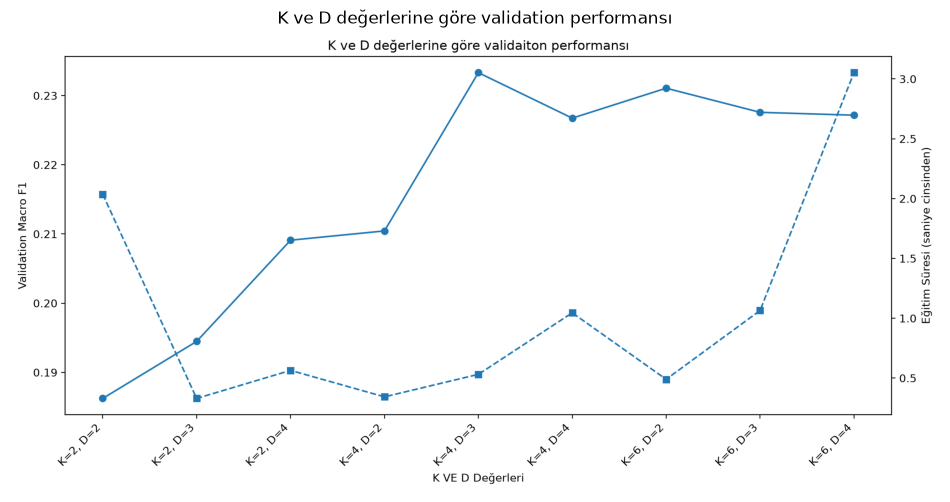

In [249]:
validation_image = Image.open(VALIDATION_GRAPH_PATH)

plt.figure(figsize=(12, 6))
plt.imshow(validation_image)
plt.axis("off")
plt.title("K ve D değerlerine göre validation performansı")
plt.show()

## PCA Görselleştirmesi

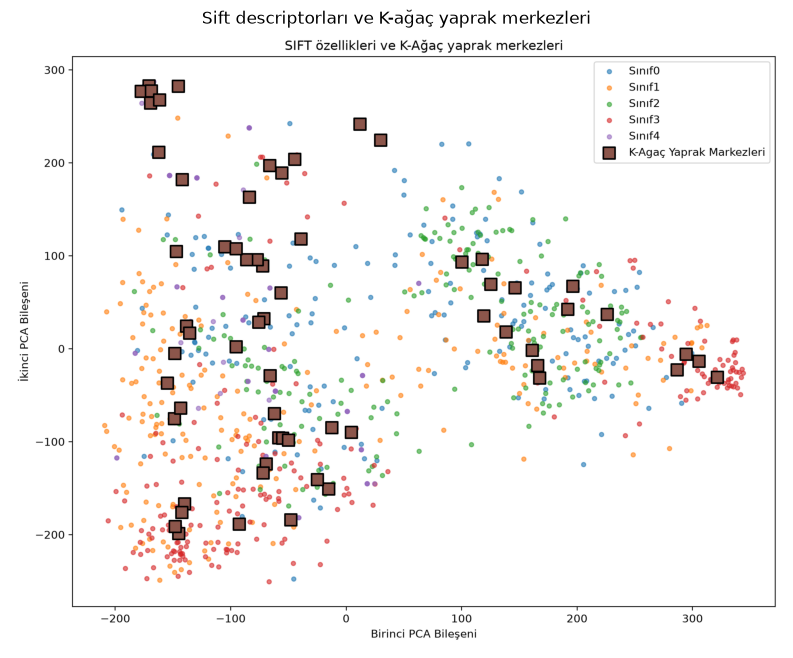

In [250]:
pca_image = Image.open(PCA_GRAPH_PATH)

plt.figure(figsize=(10, 8))
plt.imshow(pca_image)
plt.axis("off")
plt.title("Sift descriptorları ve K-ağaç yaprak merkezleri")
plt.show()

PCA görselinde rastgele seçilen eğitim descriptorları ile K-ağaç yaprak merkezlerinin iki boyutlu izdüşümü gösterilmektedir.

## Ölçek Bazlı Test Sonuçları

In [251]:
window_sizes = [128, 64, 32, 16]

for window_size in window_sizes:
    result_path = SCALE_RESULTS_DIRECTORY / f"test_results_{window_size}.txt"

    print("\n" + "=" * 50)
    print(f"{window_size}x{window_size} Test Sonuçları")

    print("=" * 50)

    print(result_path.read_text(encoding="utf-8"))
    


128x128 Test Sonuçları
Test Sonuçları: 128x128

Accuracy: 0.2699
Macro Precision: 0.2000
Macro Recall: 0.0540
Macro F1: 0.0851

Confusion Matrix
[[  0   0   0   0   0]
 [935 406 162   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]
 [  1   0   0   0   0]]

 Sınıf Sonuçları 
--------------------------------------------------
Background
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
Support: 0

Class 0
Precision: 1.0000
Recall: 0.2701
F1: 0.4254
Support: 1503

Class 1
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
Support: 0

Class 2
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
Support: 0

Class 3
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
Support: 1



64x64 Test Sonuçları
Test Sonuçları: 64x64

Accuracy: 0.3257
Macro Precision: 0.2444
Macro Recall: 0.2916
Macro F1: 0.1566

Confusion Matrix
[[ 900    9   81    1    0]
 [5082 3387 2108  373   58]
 [ 496    6  114    0    0]
 [  21    4   12    2    0]
 [ 546  105  216   10    5]]

 Sınıf Sonuçları 
---------------------------------------

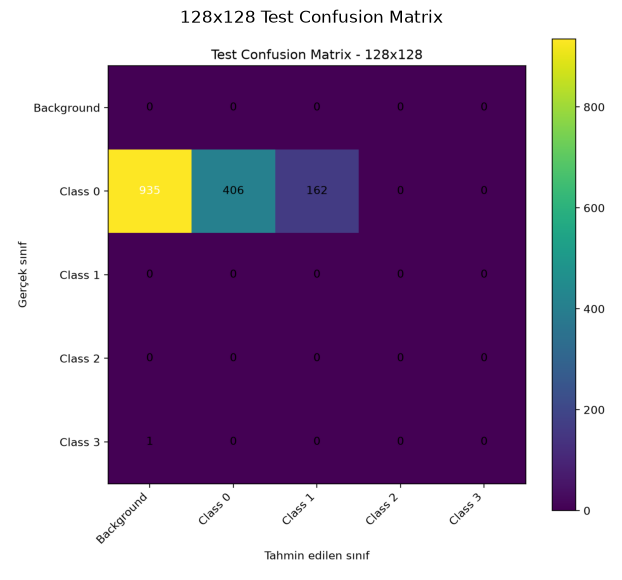

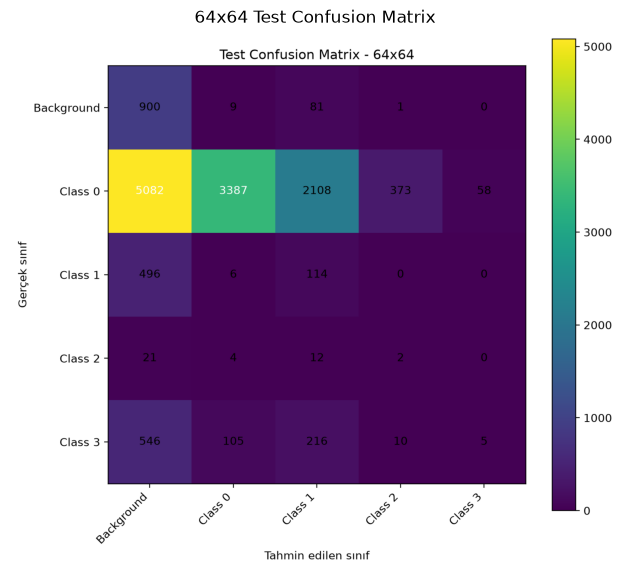

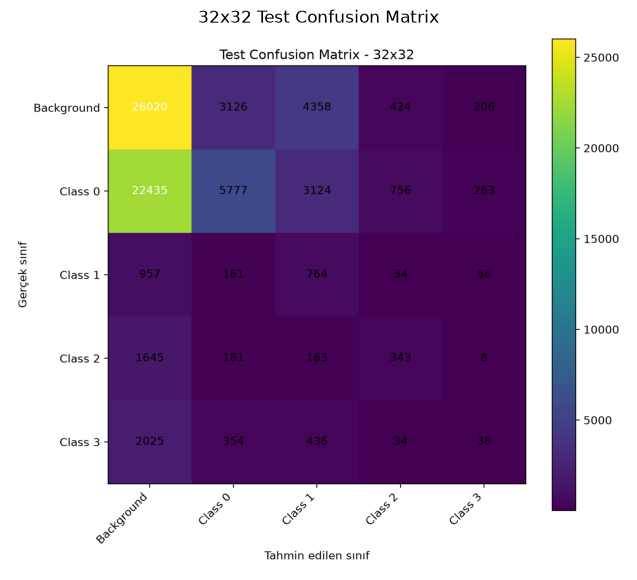

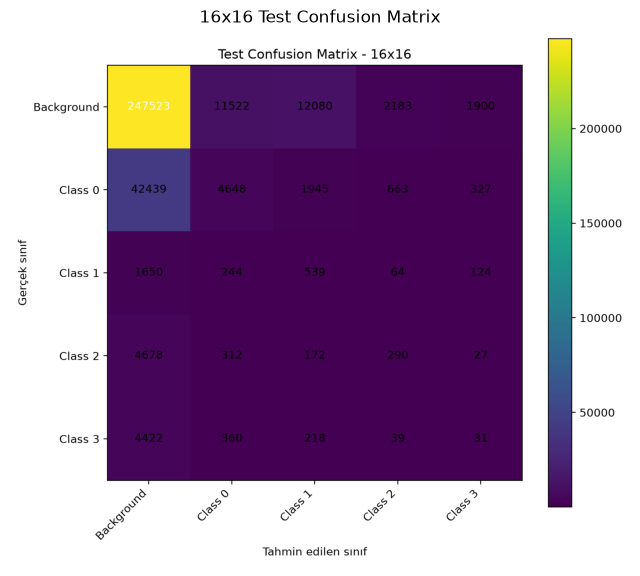

In [252]:
for window_size in window_sizes:
    image_path = SCALE_RESULTS_DIRECTORY / f"test_confusion_matrix_{window_size}.png"

    image = Image.open(image_path)

    plt.figure(figsize=(8, 7))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{window_size}x{window_size} Test Confusion Matrix")
    plt.show()

Ölçek bazlı sonuçlarda en yüksek macro f1 değeri 32x32 pencerelerde elde edilmiştir. 

## Bütün Ölçeklerin Birleşik Test Sonucu

In [253]:
print(COMBINED_TEST_RESULT_PATH.read_text(encoding="utf-8"))

Bütün ölçeklerin birleşik test sonuçları

Accuracy: 0.6808
Macro Precision: 0.2844
Macro Recall: 0.2789
Macro F1: 0.2484

Confusion Matrix
[[274443  14657  16519   2608   2106]
 [ 70891  14218   7339   1792    648]
 [  3103    411   1417     98    190]
 [  6344    497    347    635     35]
 [  6994    819    870     83     72]]

 Sınıf Sonuçları 
--------------------------------------------------
Background
Precision: 0.7586
Recall: 0.8844
F1: 0.8167
Support: 310333

Class 0
Precision: 0.4646
Recall: 0.1498
F1: 0.2266
Support: 94888

Class 1
Precision: 0.0535
Recall: 0.2715
F1: 0.0894
Support: 5219

Class 2
Precision: 0.1217
Recall: 0.0808
F1: 0.0971
Support: 7858

Class 3
Precision: 0.0236
Recall: 0.0081
F1: 0.0121
Support: 8838




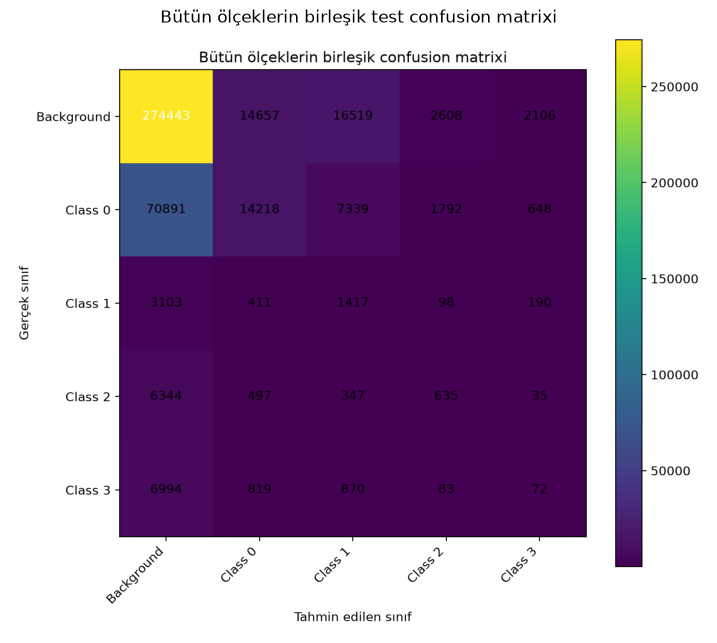

In [254]:
combined_confusion_image = Image.open(COMBINED_TEST_CONFUSION_MATRIX_PATH)

plt.figure(figsize=(9, 8))
plt.imshow(combined_confusion_image)
plt.axis("off")
plt.title("Bütün ölçeklerin birleşik test confusion matrixi")
plt.show()

Bütün ölçeklerin birleşik test sonucunda accuracy 0.6808 ve macro f1 0.2484 olarak elde edilmiştir.

## İyi ve Kötü Tespit Örnekleri

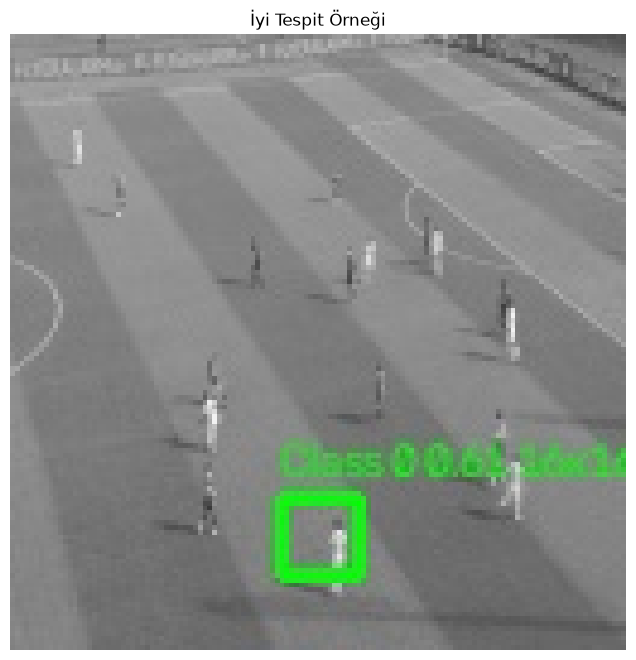

In [255]:
good_image = Image.open(GOOD_DETECTION_RESULT_PATH)

plt.figure(figsize=(10, 8))
plt.imshow(good_image)
plt.axis("off")
plt.title("İyi Tespit Örneği")
plt.show()

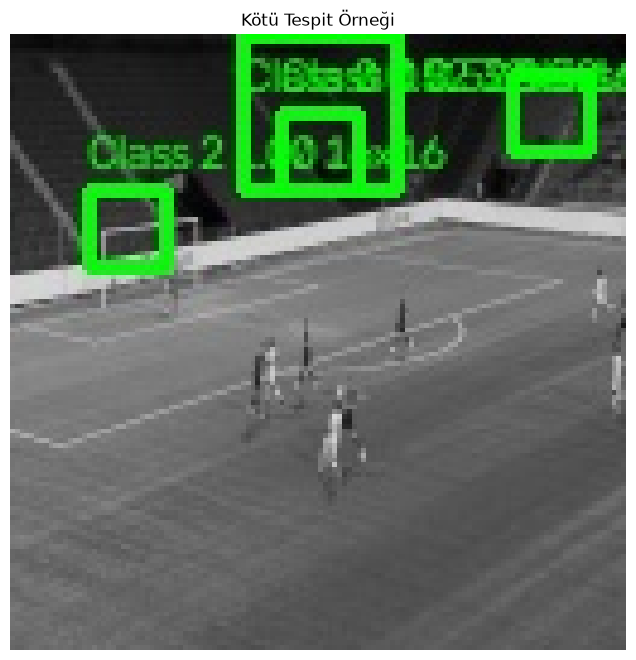

In [256]:
bad_image = Image.open(BAD_DETECTION_RESULT_PATH)

plt.figure(figsize=(10, 8))
plt.imshow(bad_image)
plt.axis("off")
plt.title("Kötü Tespit Örneği")
plt.show()

## Genel Değerlendirme

Geliştirilen yöntem sift tabanlı K-ağaç ve ölçekli sliding window yaklaşımını gerçekleştirmiştir. Model bütün sınıflar için tahmin üretebilmiş ve farklı pencere boyutlarının sonuçlar üzerindeki etkisi gözlemlenmiştir. Bu çalışma sayesinde kullanılan özelliklerin dağılımı, sınıf dengesi ve pencere boyutlarının nesne tespit performansını doğrudan etkilediği görülmüştür.